# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import ladder_ddpm#, plot_acceptance_over_time, plot_acceptance_over_position

### Sample

Note that function `plot_samples_grid` will take in a list of methods and dataset names and plot them in a grid. Function `samples_tuning` will take in a single method (ULA or MALA) and dataset name, as well as a list `step_scales_list` and `n_langevin_steps_list` and output a grid of samples for each hyperparameter. 

t 90 between 4.0 and 2.75 average acceptance 1.00 average difference 1.23
t 90 between 1.5 and 0.25 average acceptance 0.99 average difference 1.22
t 80 between 4.0 and 1.5 average acceptance 1.00 average difference 1.38
t 80 between 2.75 and 0.25 average acceptance 0.97 average difference 1.34
t 70 between 2.75 and 1.5 average acceptance 0.99 average difference 1.61
t 70 between 4.0 and 0.25 average acceptance 0.93 average difference 1.52
t 60 between 4.0 and 2.75 average acceptance 1.00 average difference 1.88
t 60 between 1.5 and 0.25 average acceptance 0.92 average difference 1.77
t 50 between 4.0 and 1.5 average acceptance 0.98 average difference 2.10
t 50 between 2.75 and 0.25 average acceptance 0.87 average difference 1.89
t 40 between 2.75 and 1.5 average acceptance 0.97 average difference 2.31
t 40 between 4.0 and 0.25 average acceptance 0.80 average difference 1.88


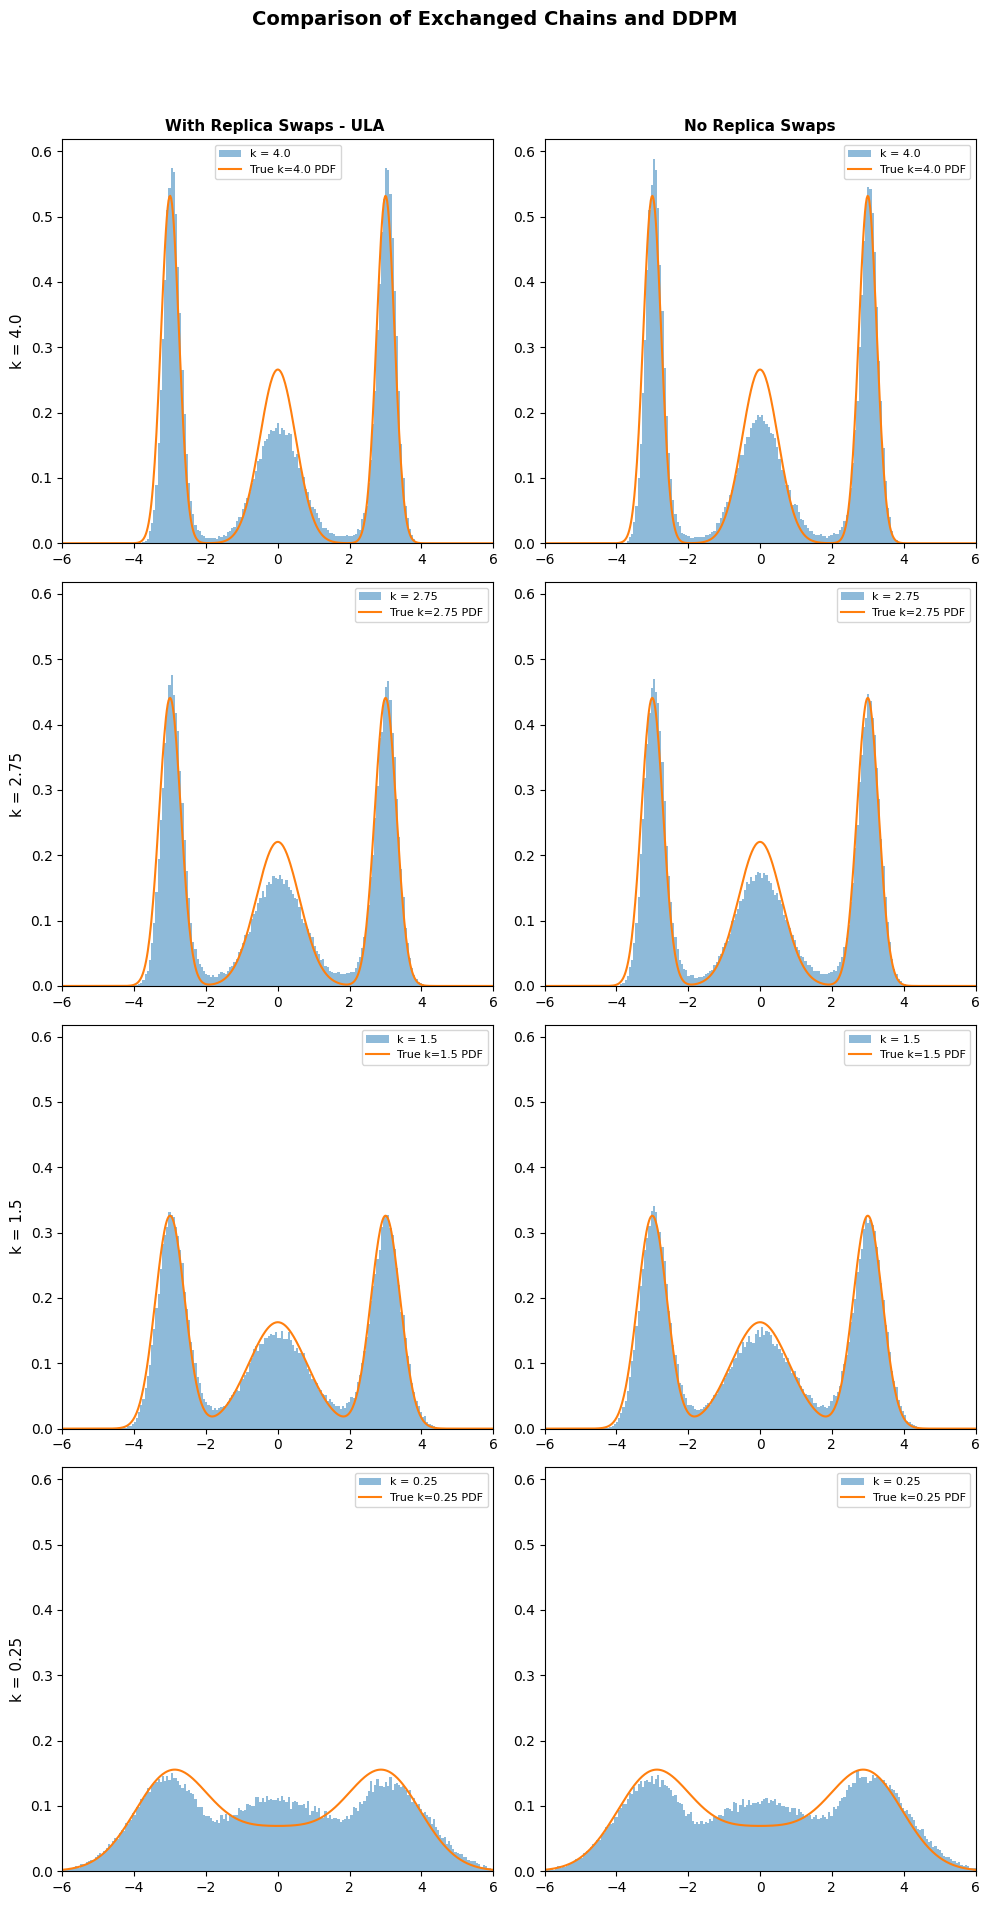

In [2]:
dataset_name = "composed"
k = 4.0
sigma = 0.6
step_scale = 1
n_langevin_steps = 5
n_replicas = 4

x_ladder, a_ladder = ladder_ddpm(dataset_name, k, sigma, step_scale, n_langevin_steps, n_replicas, x_limit=6, save_dir="figures", figsize_per_panel=(5,4), filename=None)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from collections import defaultdict

def plot_acceptance_over_time(a_ladder, n_langevin_steps, save_dir="figures", filename="swaps_acceptance_time.png"):

	fig, ax = plt.subplots(figsize=(10, 5))

	for (k_less, k_more), records in a_ladder.items():
		steps = sorted(records.keys())
		means = [records[step].mean().item() for step in steps]

		ax.plot(steps, means, label=f"k={k_less:.2f} ↔ k={k_more:.2f}", marker='o', markersize=2)

	ax.set_xlabel("Langevin Steps")
	ax.set_ylabel("Average Acceptance Rate")
	ax.set_title("Parallel Tempering Acceptance Rate Over Time")
	ax.legend()
	ax.grid(True, alpha=0.3)
	plt.tight_layout()

	save_path = os.path.join(save_dir, filename)
	plt.savefig(save_path, dpi=200)
	plt.show()

	return fig

In [5]:
from src.dataset import compute_mixture_pdf
from src.config import DATASETS

def plot_acceptance_over_position(acceptance_ladder, x_ladder, xlim = 6, save_dir="figures", filename="swaps_acceptance_position.png"):

	dataset_config =DATASETS["composed"]

	y_min = 1.0

	n_pairs = len(acceptance_ladder)

	# Collect all filled steps across all pairs
	all_steps = sorted(set(
		step for records in acceptance_ladder.values() for step in records.keys()
	))
	n_times = len(all_steps)

	fig, axes = plt.subplots(
		n_pairs, n_times,
		figsize=(5 * n_times, 3 * n_pairs),
		sharex=True
	)
	if n_pairs == 1:
		axes = axes[np.newaxis, :]
	if n_times == 1:
		axes = axes[:, np.newaxis]

	for row, ((k_less, k_more), records) in enumerate(acceptance_ladder.items()):

		x_np = x_ladder[k_less].detach().cpu().numpy().flatten()
		bins = np.linspace(x_np.min(), x_np.max(), 40)
		bin_centers = 0.5 * (bins[:-1] + bins[1:])
		bin_width = bins[1] - bins[0]

		for col, step in enumerate(all_steps):

			ax = axes[row, col]

			if step not in records:
				ax.set_visible(False)
				continue

			record = records[step].detach().cpu().numpy().flatten()

			bin_indices = np.digitize(x_np, bins) - 1
			bin_indices = np.clip(bin_indices, 0, len(bin_centers) - 1)

			bin_acceptance = np.full(len(bin_centers), np.nan)

			for b in range(len(bin_centers)):
				mask = bin_indices == b
				if mask.sum() > 0:
					bin_acceptance[b] = record[mask].mean()
					y_min = min(y_min, record[mask].mean())

			valid = ~np.isnan(bin_acceptance)
			ax.bar(bin_centers[valid], bin_acceptance[valid],
				   width=bin_width * 0.9, color="crimson", alpha=0.8)
			
			x_axis= np.linspace(-xlim, xlim, 500)
			
			pdf_flat = compute_mixture_pdf(dataset_config, x_axis, k_less)
			pdf_sharp = compute_mixture_pdf(dataset_config, x_axis, k_more)

			mean_acc = np.nanmean(bin_acceptance)
			ax.axhline(mean_acc, color='black', linestyle='--', linewidth=1,
					   label=f"mean={mean_acc:.3f}")
			
			ax.plot(x_axis, pdf_flat, label=f"True k={k_less} PDF")
			ax.plot(x_axis, pdf_sharp, label=f"True k={k_more} PDF")

			ax.set_ylabel("Acceptance rate")
			ax.set_xlabel("x")
			ax.set_title(f"k={k_less:.2f}↔{k_more:.2f}, step={step}")
			ax.set_xlim(-xlim,xlim)
			ax.legend(fontsize=8)

	for row in range(n_pairs):
		for col in range(n_times):
			if axes[row, col].get_visible():
				axes[row, col].set_ylim(y_min * 0.98, 1)

	fig.suptitle("Acceptance Rate by Position", fontsize=14, y=1.01)
	plt.tight_layout()

	save_path = os.path.join(save_dir, filename)
	plt.savefig(save_path, dpi=200)
	plt.show()
	return fig